In [1]:
import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import pandas as pd
from numba import njit
import awkward.numba

import matplotlib as mpl

plt.style.use(hep.style.CMS)
%matplotlib inline

In [2]:
filenameS = '/eos/user/a/aperego/tagger/tree_Zjj_10k.root'
fileSignal = uproot.open(filenameS)

filenameB = '/eos/user/a/aperego/tagger/tree_DY_10k.root'
fileBkg = uproot.open(filenameB)

In [3]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

In [4]:
fS_LHEParticles = load_branch_with_highest_cycle(fileSignal, "LHEParticles")
fS_GenJets = load_branch_with_highest_cycle(fileSignal, "GenJets")
fS_GenParticles = load_branch_with_highest_cycle(fileSignal, "GenParticles")

fB_LHEParticles = load_branch_with_highest_cycle(fileBkg, "LHEParticles")
fB_GenJets = load_branch_with_highest_cycle(fileBkg, "GenJets")
fB_GenParticles = load_branch_with_highest_cycle(fileBkg, "GenParticles")

In [5]:
print(fS_LHEParticles.keys())
print(fS_GenJets.keys())
print(fS_GenParticles.keys())

['LHEPart_pt', 'LHEPart_eta', 'LHEPart_phi', 'LHEPart_mass', 'LHEPart_pdgId', 'LHEPart_status']
['GenJet_pt', 'GenJet_eta', 'GenJet_phi', 'GenJet_mass', 'GenJet_nConstituents', 'GenJet_constituents']
['nGenPart', 'GenPart_pt', 'GenPart_eta', 'GenPart_phi', 'GenPart_mass', 'GenPart_pdgId']


In [6]:
LHEParticles_s = fS_LHEParticles.arrays(fS_LHEParticles.keys())
GenJets_s = fS_GenJets.arrays(fS_GenJets.keys())
GenParticles_s = fS_GenParticles.arrays(fS_GenParticles.keys())

LHEParticles_b = fB_LHEParticles.arrays(fB_LHEParticles.keys())
GenJets_b = fB_GenJets.arrays(fB_GenJets.keys())
GenParticles_b = fB_GenParticles.arrays(fB_GenParticles.keys())

In [7]:
def getJetConstituents(i, nConst, allConst):
    return allConst[sum(nConst[:i]):sum(nConst[:i+1])]

@njit
def getJetConstituents_numba(i, nConst, allConst):
    start = 0
    for j in range(i):
        start += nConst[j]
    end = start + nConst[i]
    return allConst[start:end]

In [8]:
def getManyJetsConstituents(i, j, nConst, allConst):
    return allConst[sum(nConst[:i]):sum(nConst[:j+1])]

In [9]:
@njit
def getAllJetsConstituents(GenJets):
    all_jetConst = []
    for ev in range(len(GenJets)):
        jetConst = []
        nConst = GenJets.GenJet_nConstituents
        allConst = GenJets.GenJet_constituents
        for jet in range(len(nConst[ev])):
            jetConst.append(getJetConstituents_numba(jet, nConst[ev], allConst[ev]))
        all_jetConst.append(jetConst)
    return all_jetConst

In [10]:
# constituents_s = ak.from_iter(getAllJetsConstituents(GenJets_s))
# constituents_b = ak.from_iter(getAllJetsConstituents(GenJets_b))

In [11]:
# ak.to_json(constituents_s, "constituents_s.txt")
# ak.to_json(constituents_b, "constituents_b.txt")

In [17]:
import pathlib

In [18]:
constituents_s = ak.from_json(pathlib.Path("constituents_s.json"))
constituents_b = ak.from_json(pathlib.Path("constituents_b.json"))

## features

In [19]:
def wrapInPhi(phi):
    """Map angle values to the range [-pi, pi]."""
    return (phi + np.pi) % (2 * np.pi) - np.pi

@njit
def wrapInPhi_numba(phi):
    x = (phi + np.pi) % (2 * np.pi) - np.pi
    return x

## input to GNN

In [20]:
MAX_CON = 50
MIN_PT = 10

In [21]:
def getJetDataFrame(GenJets, genParticles, constituents, isSig=True):
    EVENTS=ak.sum(ak.count(GenJets.GenJet_pt[GenJets.GenJet_pt>MIN_PT], axis=1))
    all_data = np.zeros((EVENTS, MAX_CON, 5))
    idx = 0
    for ev in range(len(genParticles.GenPart_pt)):
        GP_pt = genParticles.GenPart_pt[ev]
        GP_eta = genParticles.GenPart_eta[ev]
        GP_phi = genParticles.GenPart_phi[ev]
        GP_mass = genParticles.GenPart_mass[ev]
        GP_pdgId = genParticles.GenPart_pdgId[ev]
        const_ev = constituents[ev]
        for jet in range(len(const_ev)):
            if GenJets.GenJet_pt[ev][jet]<10: continue
            nConst = min(len(constituents[ev][jet]), MAX_CON)
            const_jet = const_ev[jet]
            if len(constituents[ev][jet]) > MAX_CON:
                sorted_indices = np.argsort(genParticles.GenPart_pt[ev])[::-1]
                top_indices = sorted_indices[:MAX_CON]
                GPinJet_pt = GP_pt[top_indices]
                GPinJet_eta = GP_eta[top_indices]
                GPinJet_phi = GP_phi[top_indices]
                GPinJet_mass = GP_mass[top_indices]
                GPinJet_pdgId = GP_pdgId[top_indices]
                
                all_data[idx][:,0] = GPinJet_pt # pt, eta, phi ..
                all_data[idx][:,1] = GPinJet_eta # pt, eta, phi ..
                all_data[idx][:,2] = GPinJet_phi # pt, eta, phi ..
                all_data[idx][:,3] = GPinJet_mass # pt, eta, phi ..
                all_data[idx][:,4] = GPinJet_pdgId # pt, eta, phi ..
            else:
                all_data[idx][:nConst,0] = GP_pt[const_jet]
                all_data[idx][:nConst,1] = GP_eta[const_jet]
                all_data[idx][:nConst,2] = GP_phi[const_jet]
                all_data[idx][:nConst,3] = GP_mass[const_jet]
                all_data[idx][:nConst,4] = GP_pdgId[const_jet]
            idx += 1
    if isSig:
        all_label = np.ones(EVENTS)
    else:
        all_label = np.zeros(EVENTS)
    return all_data, all_label

In [22]:
# sigData, sigLabel = getJetDataFrame(GenJets_s, GenParticles_s, constituents_s, True)
# bkgData, bkgLabel = getJetDataFrame(GenJets_b, GenParticles_b, constituents_b, False)

In [23]:
# np.save("sigData.npy", sigData)
# np.save("sigLabel.npy", sigLabel)
# np.save("bkgData.npy", bkgData)
# np.save("bkgLabel.npy", bkgLabel)

In [24]:
sigData = np.load("sigData.npy")
sigLabel = np.load("sigLabel.npy")
bkgData = np.load("bkgData.npy")
bkgLabel = np.load("bkgLabel.npy")

In [29]:
allData = np.concatenate((sigData, bkgData))

In [33]:
allData.shape

(121083, 50, 5)

In [34]:
allLabel = np.concatenate((sigLabel, bkgLabel))

In [35]:
allLabel.shape

(121083,)

## evaluate scaling

In [25]:
# TODO
# Assuming df is your DataFrame with the mentioned columns
# columns_to_plot = ['pt', 'eta', 'phi', 'mass', 'ncostituents', 'jetpull_m', 'jetpull_eta', 'jetpull_phi']

# # Create histograms for each feature
# df[columns_to_plot].hist(bins=30, figsize=(10, 10))
# plt.suptitle('Feature Distributions (Before Scaling)')
# plt.tight_layout()
# plt.show()

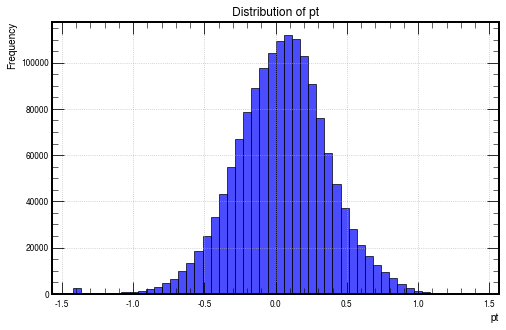

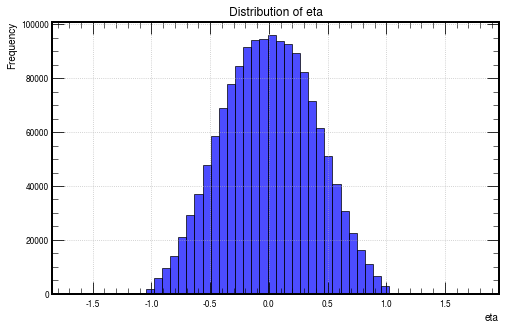

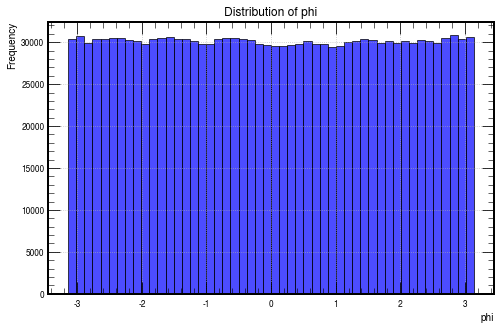

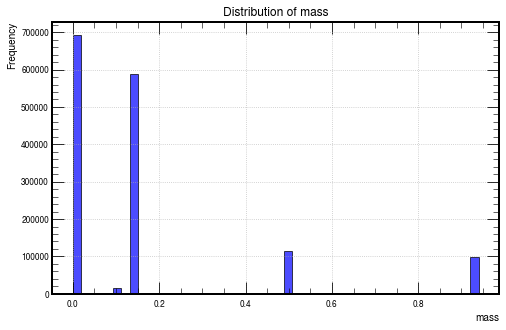

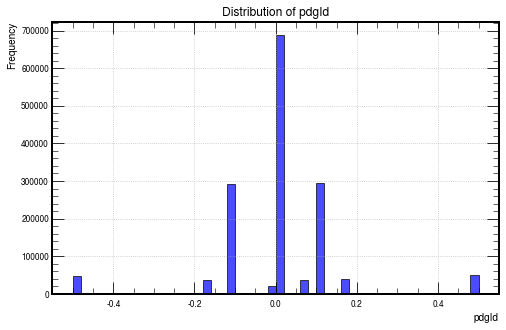

In [36]:
# to be tested!!
feature_labels = ["pt", "eta", "phi", "mass", "pdgId"]

# Loop over each feature (column in `all_data`)
for i, label in enumerate(feature_labels):
    # Extract all non-zero entries for the current feature across all events and constituents
    feature_data = allData[:, :, i]
    mask = allData[:, :, 0]
    non_zero_data = feature_data[mask != 0]  # Exclude entries where GP_pt == 0
    
    # Plot the histogram
    plt.figure(figsize=(8, 5))
    if i==0:
        non_zero_data = np.log(non_zero_data)/5
        non_zero_data= np.clip(non_zero_data, a_min=-max(non_zero_data), a_max = max(non_zero_data))
    if i==1:
        non_zero_data = non_zero_data/5
    if i==4:
        non_zero_data = non_zero_data/2000
        non_zero_data= np.clip(non_zero_data, a_min=-0.5, a_max = 0.5)

    plt.hist(non_zero_data, bins=50, alpha=0.7, color='b', edgecolor='black')
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

## train test split

In [37]:
# allData = np.concatenate((sigData,bkgData))
# allLabel = np.concatenate((sigLabel,bkgLabel))

In [38]:
# allLabel.shape

In [39]:
from sklearn.model_selection import train_test_split

# Split into training and remaining dataset
X_train, X_rem, y_train, y_rem = train_test_split(allData, allLabel, train_size=0.9)
X_valid, X_test, y_valid, y_test = train_test_split(X_rem,y_rem, test_size=0.5)

## GNN

In [40]:
# install Pytorch Geometric
import torch
print(torch.__version__)

import torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import FixedPoints
from sklearn.model_selection import train_test_split
from torch_cluster import knn_graph

2.5.1


In [41]:
def custom_knn_graph(pos, k):
    num_points = pos.size(0)
    
    # Extract eta and phi
    eta = pos[:, 0]
    phi = pos[:, 1]
    
    # Compute pairwise eta and phi differences
    eta_diff = eta.unsqueeze(1) - eta.unsqueeze(0)
    phi_diff = phi.unsqueeze(1) - phi.unsqueeze(0)
    
    # Apply periodic boundary conditions to phi differences
    phi_diff = torch.remainder(phi_diff + torch.pi, 2 * torch.pi) - torch.pi
    
    # Compute L2 distances in eta-phi space
    distances = torch.sqrt(eta_diff**2 + phi_diff**2)
    
    # Sort to get indices of the k-nearest neighbors for each point
    sorted_indices = distances.argsort(dim=1)
    
    # Initialize lists to hold edge index pairs
    row_indices = []
    col_indices = []
    
    for i in range(num_points):
        # Get the sorted indices of neighbors for the current point, excluding self-loop (i.e., starting from 1)
        neighbors = sorted_indices[i, 1:k+1]
        
        # If there are fewer than `k` neighbors, pad with self-loop indices to make it consistent
        if neighbors.size(0) < k:
            neighbors = torch.cat([neighbors, neighbors.new_full((k - neighbors.size(0),), i)])
        
        # Append the source node and its neighbors
        row_indices.append(torch.full((k,), i, dtype=torch.long))
        col_indices.append(neighbors)
    
    # Stack all row and column indices
    row_indices = torch.cat(row_indices)
    col_indices = torch.cat(col_indices)
    
    # Construct the edge_index tensor
    edge_index = torch.stack([row_indices, col_indices], dim=0)
    
    return edge_index

In [42]:
class MyGraphDataset(torch_geometric.data.Dataset):
    def __init__(self, data_f, data_l, k=5, transform=None, pre_transform=None):
        super(MyGraphDataset, self).__init__(transform, pre_transform)
        self.data_f = data_f #features
        self.data_l = data_l #labels
        self.num_samples = len(data_f)
        self.k = k # number of nearest neighbors

    def len(self):
        return self.num_samples

    def get(self, idx):
        graph_data = self.data_f[idx]
        graph_label = self.data_l[idx]
        
        #features: pt, eta, phi, mass, pdgId

        # select real jet constituents (pt > 0)
        sel = graph_data[:,0]>0
        pos_tmp = graph_data[sel]

        pt = np.log(torch.tensor(pos_tmp[:,0], dtype=torch.float32))/5
        pt = torch.clamp(pt, -1.5, 1.5)
        eta = torch.tensor(pos_tmp[:,1], dtype=torch.float32)/5
        phi = torch.tensor(pos_tmp[:,2], dtype=torch.float32)
        mass = torch.tensor(pos_tmp[:,3], dtype=torch.float32)
        pid = torch.tensor(pos_tmp[:,4], dtype=torch.float32)/2000
        pid = torch.clamp(pid, -0.5, 0.5)
        
        pos = torch.stack([eta,phi], dim=1)
        x   = torch.stack([pt, pid], dim=1)
        y   = torch.tensor(np.asarray(graph_label), dtype=torch.long) #targets

        # compute edge_index (using pos)
        # define how to link points KNNGraph,knn_graph,radius_graph
        # edge_index = knn_graph(pos, k=self.k, loop=False)
        edge_index = custom_knn_graph(pos, 5)
        
        # pyg data object
        data = Data(x=x, y=y, pos=pos, edge_index=edge_index, category=y)

        return data
    
print("train: "),print(X_train.shape), print(y_train.shape)
print("vali: "),print(X_valid.shape), print(y_valid.shape)
print("test: "),print(X_test.shape), print(y_test.shape)

train: 
(108974, 50, 5)
(108974,)
vali: 
(6054, 50, 5)
(6054,)
test: 
(6055, 50, 5)
(6055,)


(None, None, None)

In [43]:
# number of nearest neighbors
k = 5

# Create Datasets
trainset = MyGraphDataset(X_train, y_train, k=k)
validset = MyGraphDataset(X_valid, y_valid, k=k)
testset = MyGraphDataset(X_test, y_test, k=k)

# Create DataLoaders
trainloader = DataLoader(trainset, batch_size=1024, shuffle=True, drop_last=True,num_workers=8)
validloader = DataLoader(validset, batch_size=1024, shuffle=False, drop_last=False,num_workers=8)
testloader = DataLoader(testset, batch_size=128, shuffle=False, drop_last=False)

In [44]:
for i in range(2):
    print(trainset[i])

Data(x=[4, 2], edge_index=[2, 20], y=0, pos=[4, 2], category=0)
Data(x=[11, 2], edge_index=[2, 55], y=0, pos=[11, 2], category=0)


In [45]:
d = next(iter(trainloader))

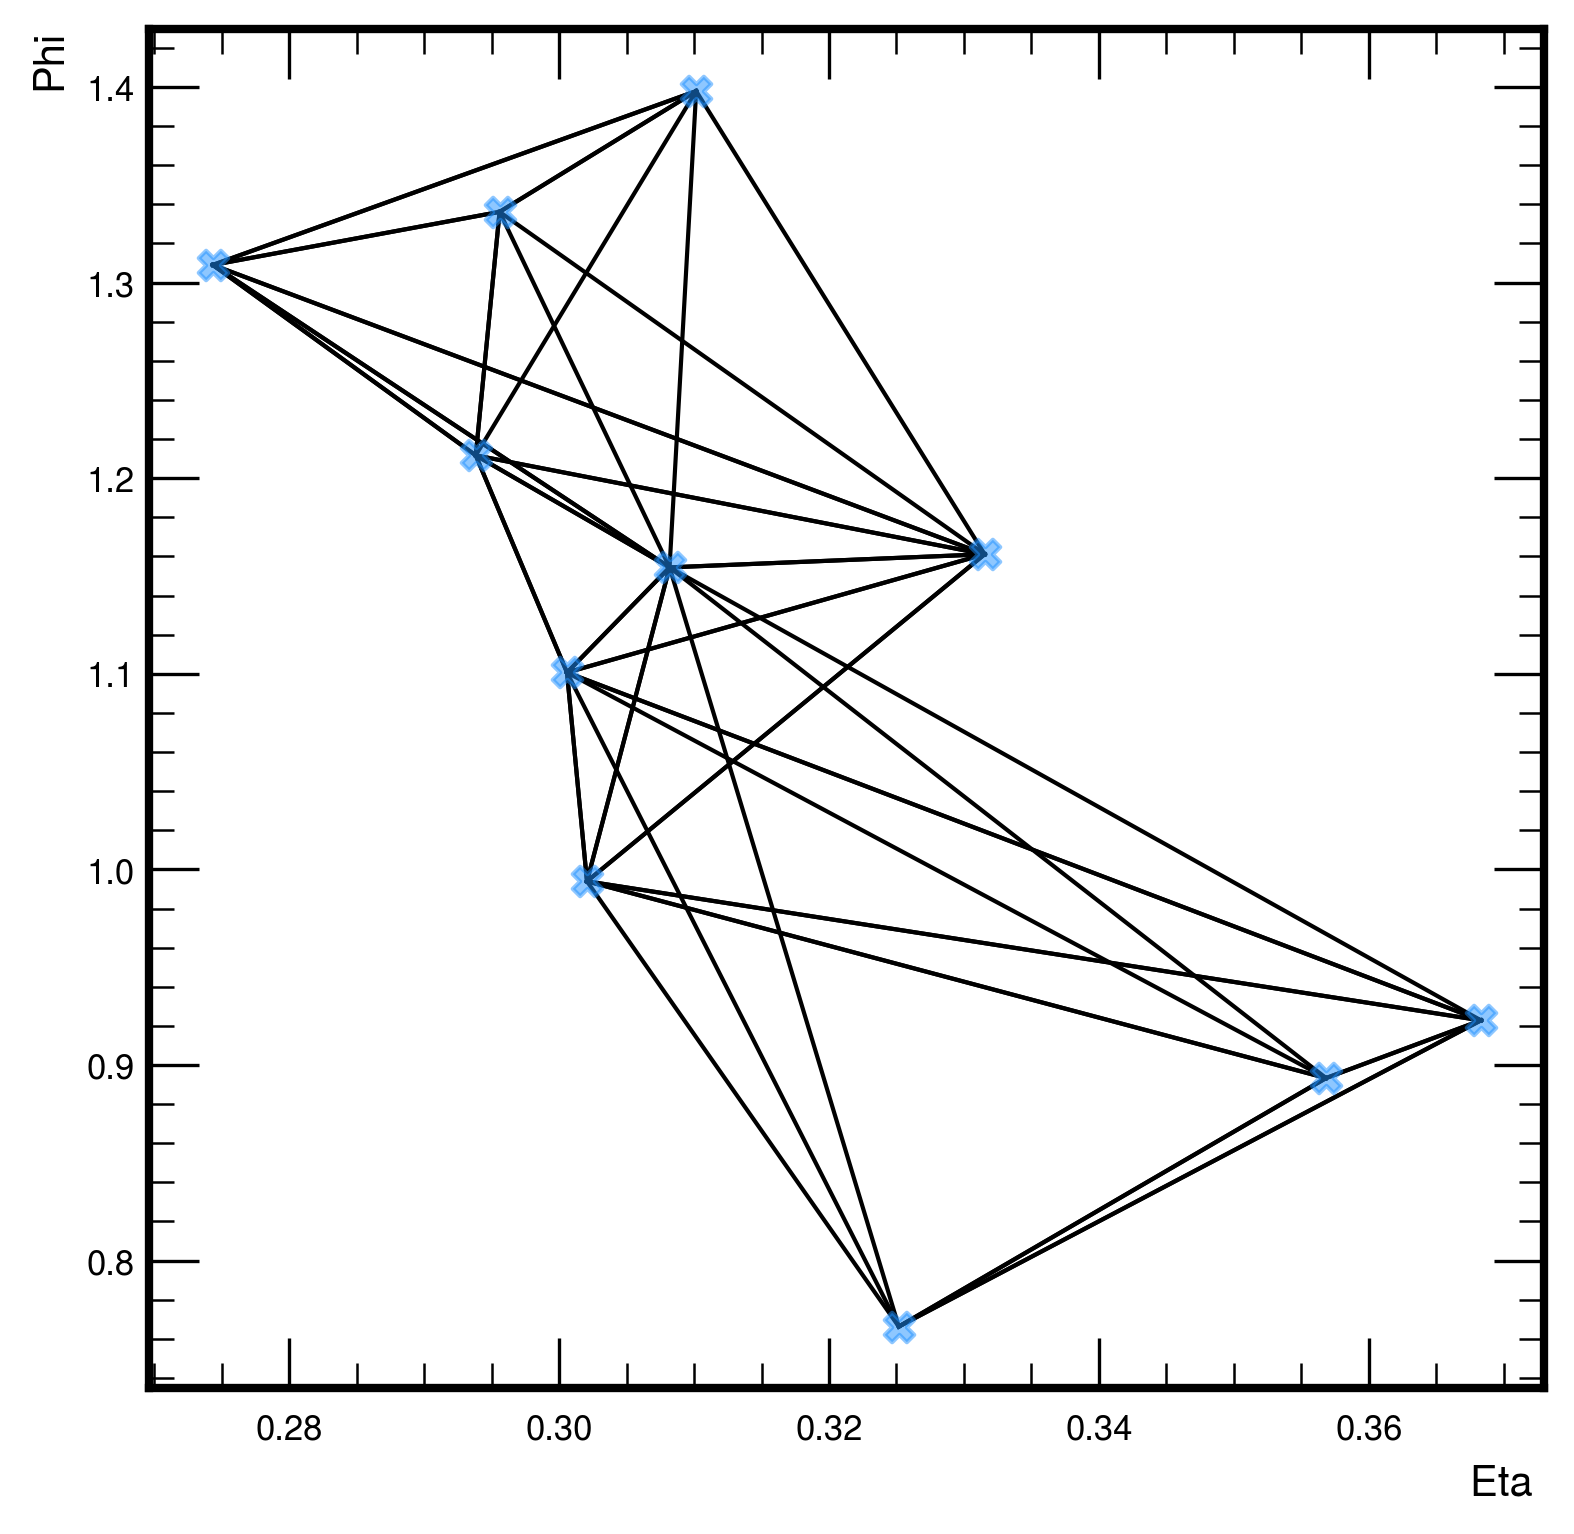

In [49]:
def visualize_points(pos, x, edge_index=None):
    fig = plt.figure(figsize=(6, 6), dpi=300)
    if edge_index is not None:
        for (src, dst) in edge_index.t().tolist():
             src = pos[src].tolist()
             dst = pos[dst].tolist()
             plt.plot([src[0], dst[0]], [src[1], dst[1]], linewidth=1, color='black')

    x = list(pos[2:, 0])+list(pos[:2, 0])
    y = list(pos[2:, 1])+list(pos[:2, 1])
    plt.scatter(x, y, c = 'dodgerblue', marker='X',alpha=0.5, s=50, zorder=1000)
#     plt.xlim((-5,5))
#     plt.ylim((-np.pi, np.pi))
    plt.xlabel('Eta ')
    plt.ylabel('Phi')
    plt.show()

data = trainset[1]

visualize_points(data.pos, data.x, data.edge_index)

In [47]:
from matplotlib import colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())
def get_color(index):
    wrapped_index = index % len(colors)
    return colors[wrapped_index]

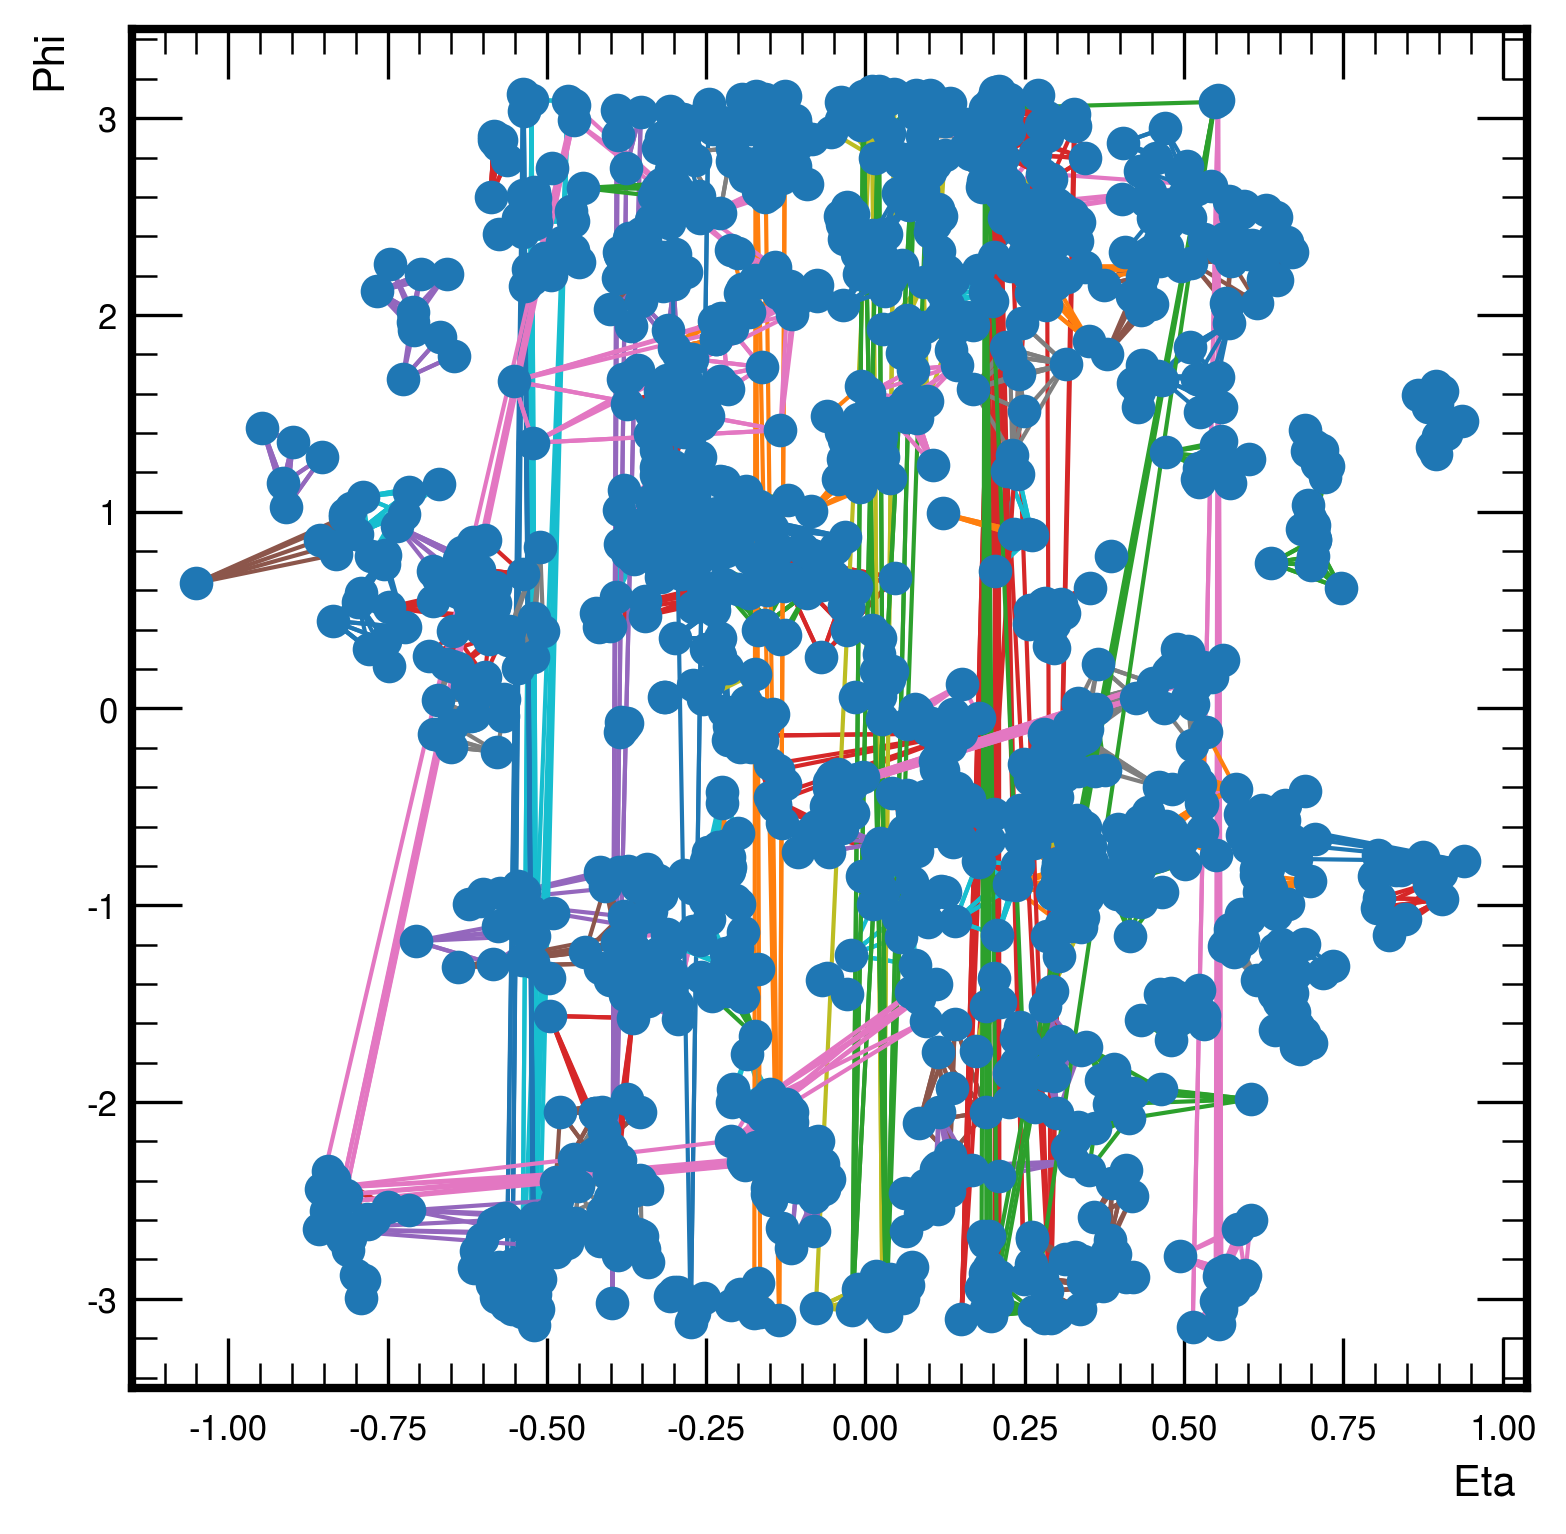

In [146]:
def visualize_batch(pos, x, edge_index=None, batch=None):
    fig = plt.figure(figsize=(6, 6), dpi=300)
        
    if edge_index is not None:
        for (src, dst) in edge_index.t().tolist():
             if batch is not None:
                 c=get_color(batch[src])
             else:
                 c="black"
             src = pos[src].tolist()
             dst = pos[dst].tolist()
             
             plt.plot([src[0], dst[0]], [src[1], dst[1]], linewidth=1, color=c)
            
   
    plt.scatter(pos[:, 0], pos[:, 1], s=50, zorder=1000)
   

    plt.axis('on')
#     plt.xlim((-5,5))
#     plt.ylim((-np.pi, np.pi))
    plt.xlabel('Eta ')
    plt.ylabel('Phi')
    plt.show()
data = next(iter(testloader))
visualize_batch(data.pos,data.x, data.edge_index,data.batch)

In [147]:
# GNN model in pytorch geometric: we'll use a simple convolutional GNN based on the GCNConv message passing graph convolution
# https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html


import torch.nn as nn
from torch_geometric.nn import GCNConv, global_max_pool,PointNetConv,global_mean_pool
from torch_geometric.nn.norm import BatchNorm
from torch_geometric.utils import dropout_node,dropout_edge
import torch.nn.functional as F

class GNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN, self).__init__()
        self.pre_feat = nn.Linear(input_dim, hidden_dim)
        self.pre_feat2 = nn.Linear(hidden_dim, hidden_dim)
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.bn1 =BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 =BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 =BatchNorm(hidden_dim)
        #self.conv4 = GCNConv(hidden_dim, hidden_dim)
        #self.bn4 =BatchNorm(hidden_dim)
        #self.conv5 = GCNConv(hidden_dim, hidden_dim)
        #self.bn5 =BatchNorm(hidden_dim)
        #self.conv6 = GCNConv(hidden_dim, hidden_dim)
        #self.bn6 =BatchNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        # when loading data use .unsqueeze(1) if the data has only one column
        pos, feat, edge_index, batch = data.pos, data.x, data.edge_index, data.batch
        feat = torch.cat((feat, pos), dim=1)

        feat = F.relu(self.pre_feat(feat))
        feat = F.relu(self.pre_feat2(feat))
        feat = F.dropout(feat, p=0.5, training=self.training)

        x = F.relu(self.conv1(feat, edge_index))
        x = self.bn1(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.bn2(x)
#         x = F.relu(self.conv3(x, edge_index))
#         x = self.bn3(x)
        x = x + feat
        x = global_mean_pool(x, batch)  # Aggregate node features
        x = F.dropout(x, p=0.5, training=self.training)
        x =  F.relu(self.fc(x))
        x = self.fc2(x)
        return x

In [148]:
# test the model on one batch
from torch_geometric.nn import summary
model = GNN(input_dim=4, hidden_dim=128, output_dim=4)
data = next(iter(trainloader))
output = model(data)

/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

In [149]:
print(output.shape)
print(summary(model, data))

torch.Size([1024, 4])
+----------------------------+--------------------------+----------------+----------+
| Layer                      | Input Shape              | Output Shape   | #Param   |
|----------------------------+--------------------------+----------------+----------|
| GNN                        | [12792, 12792]           | [1024, 4]      | 84,484   |
| ├─(pre_feat)Linear         | [12792, 4]               | [12792, 128]   | 640      |
| ├─(pre_feat2)Linear        | [12792, 128]             | [12792, 128]   | 16,512   |
| ├─(conv1)GCNConv           | [12792, 128], [2, 63960] | [12792, 128]   | 16,512   |
| ├─(bn1)BatchNorm           | [12792, 128]             | [12792, 128]   | 256      |
| │    └─(module)BatchNorm1d | [12792, 128]             | [12792, 128]   | 256      |
| ├─(conv2)GCNConv           | [12792, 128], [2, 63960] | [12792, 128]   | 16,512   |
| ├─(bn2)BatchNorm           | [12792, 128]             | [12792, 128]   | 256      |
| │    └─(module)BatchNorm1d | [

In [150]:
import torch_scatter
print(torch_scatter.__version__)

2.1.1


In [151]:
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# move model to GPU
model = GNN(input_dim=4, hidden_dim=128, output_dim=8).to(device)

# initialize loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, verbose=True)

# training loop
num_epochs = 50
train_losses, valid_losses = [], []
train_accuracies, valid_accuracies = [], []
best_valid_loss = float('inf')

all_true_labels_lastEpoch = []
all_pred_probs_lastEpoch = []

for epoch in range(num_epochs):
    start_time = time.time()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    # set model to training mode
    model.train()
    for i, batch in enumerate(trainloader):
        batch = batch.to(device)
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch.y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch.y.size(0)
        train_correct += (predicted == batch.y).sum().item()

    # Validation
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    # Variables to store true labels and predicted probabilities for ROC/AUC calculation
    all_true_labels = []
    all_pred_probs = []

    # set model to evaluation mode
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(validloader):
            batch = batch.to(device)
            outputs = model(batch)
            loss = criterion(outputs, batch.y)
            valid_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            valid_total += batch.y.size(0)
            valid_correct += (predicted == batch.y).sum().item()

            # Store true labels and predicted probabilities
            all_true_labels.extend(batch.y.cpu().numpy())
            all_pred_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())  # Probabilities for class 1

    # Calculate epoch metrics
    train_accuracy = 100 * train_correct / train_total
    valid_accuracy = 100 * valid_correct / valid_total
    epoch_time = time.time() - start_time

    # Print and store metrics
    print('Epoch %d: train loss: %.3f, train acc: %.3f%%, valid loss: %.3f, valid acc: %.3f%%, time: %.3fs' %
          (epoch + 1, train_loss / len(trainloader), train_accuracy,
           valid_loss / len(validloader), valid_accuracy, epoch_time))

    train_losses.append(train_loss / len(trainloader))
    valid_losses.append(valid_loss / len(validloader))
    train_accuracies.append(train_accuracy)
    valid_accuracies.append(valid_accuracy)
    scheduler.step(valid_accuracy)
    print("lr: ", optimizer.param_groups[0]['lr'])

    # Save model if validation loss improves
    if valid_loss / len(validloader) < best_valid_loss:
        best_valid_loss = valid_loss / len(validloader)
        torch.save(model.state_dict(), 'best_model_gnn.pth')
        print("Model saved!")
    
    
    all_true_labels_lastEpoch = all_true_labels
    all_pred_probs_lastEpoch = all_pred_probs


cuda


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

Epoch 1: train loss: 0.728, train acc: 55.644%, valid loss: 0.683, valid acc: 56.359%, time: 26.554s
lr:  0.03
Model saved!


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

Epoch 2: train loss: 0.673, train acc: 59.317%, valid loss: 0.671, valid acc: 57.301%, time: 25.733s
lr:  0.03
Model saved!


...

Epoch 48: train loss: 0.654, train acc: 61.533%, valid loss: 0.651, valid acc: 62.075%, time: 25.979s
lr:  0.0075
Model saved!


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

Epoch 49: train loss: 0.653, train acc: 61.587%, valid loss: 0.652, valid acc: 61.843%, time: 26.641s
lr:  0.0075


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/si

Epoch 50: train loss: 0.654, train acc: 61.367%, valid loss: 0.652, valid acc: 61.430%, time: 25.547s
lr:  0.0075


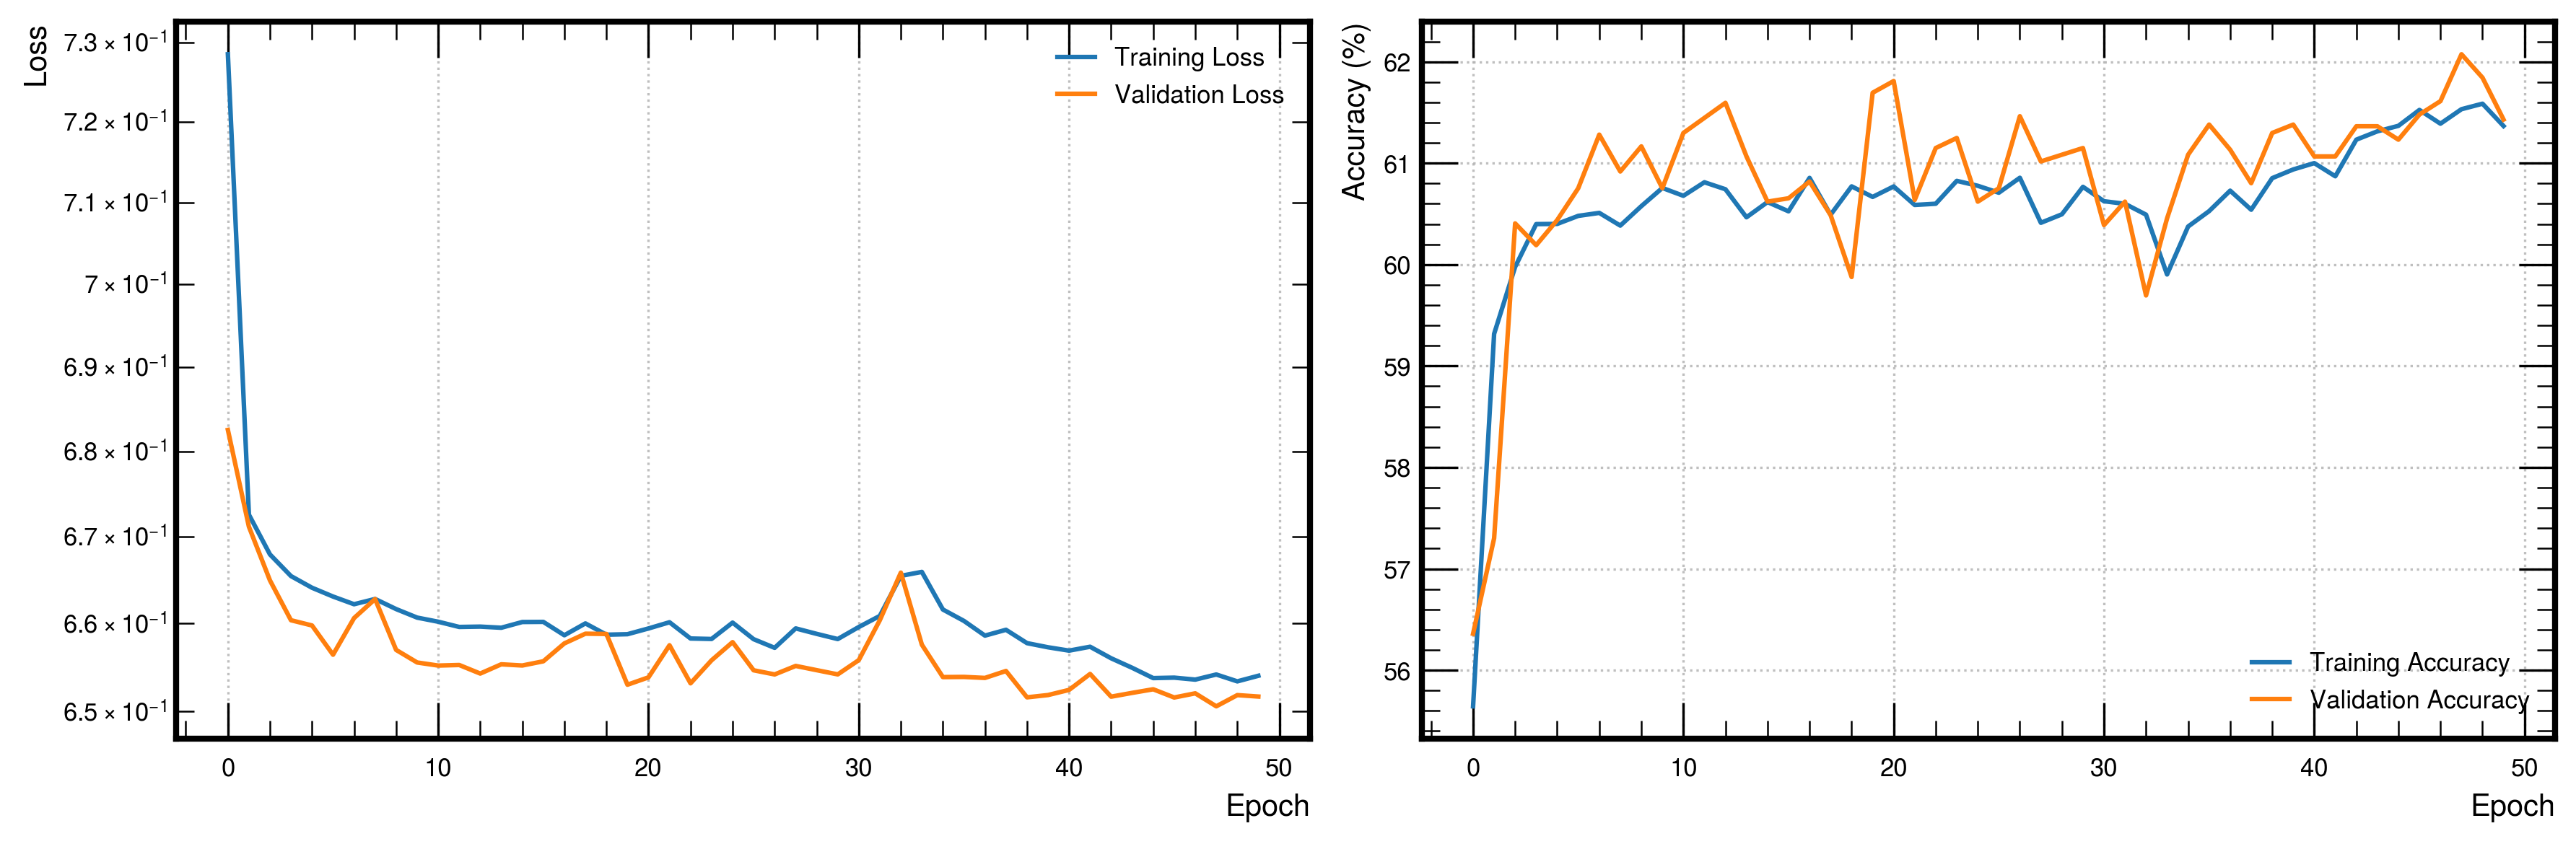

In [155]:
# plot loss and accuracy vs epoch for training and validation

# Plot loss and accuracy
plt.figure(figsize=(12, 4), facecolor='white', dpi=300)

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid("on")
plt.yscale("log")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(valid_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid("on")

plt.tight_layout()
plt.savefig("lossAndAccNew.png")

In [52]:
# # Calculate ROC and AUC for validation
# fpr, tpr, _ = roc_curve(all_true_labels_lastEpoch, all_pred_probs_lastEpoch)
# roc_auc = auc(fpr, tpr)

# # Plot ROC curve for validation
# plt.figure(dpi=300, facecolor='white',figsize=(6,6))
# # plt.axis("equal")
# plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.0])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title(f'Receiver Operating Characteristic (ROC) - Epoch {epoch + 1}')
# plt.legend(loc='lower right')
# plt.grid(True)
# plt.savefig("ROC.png")

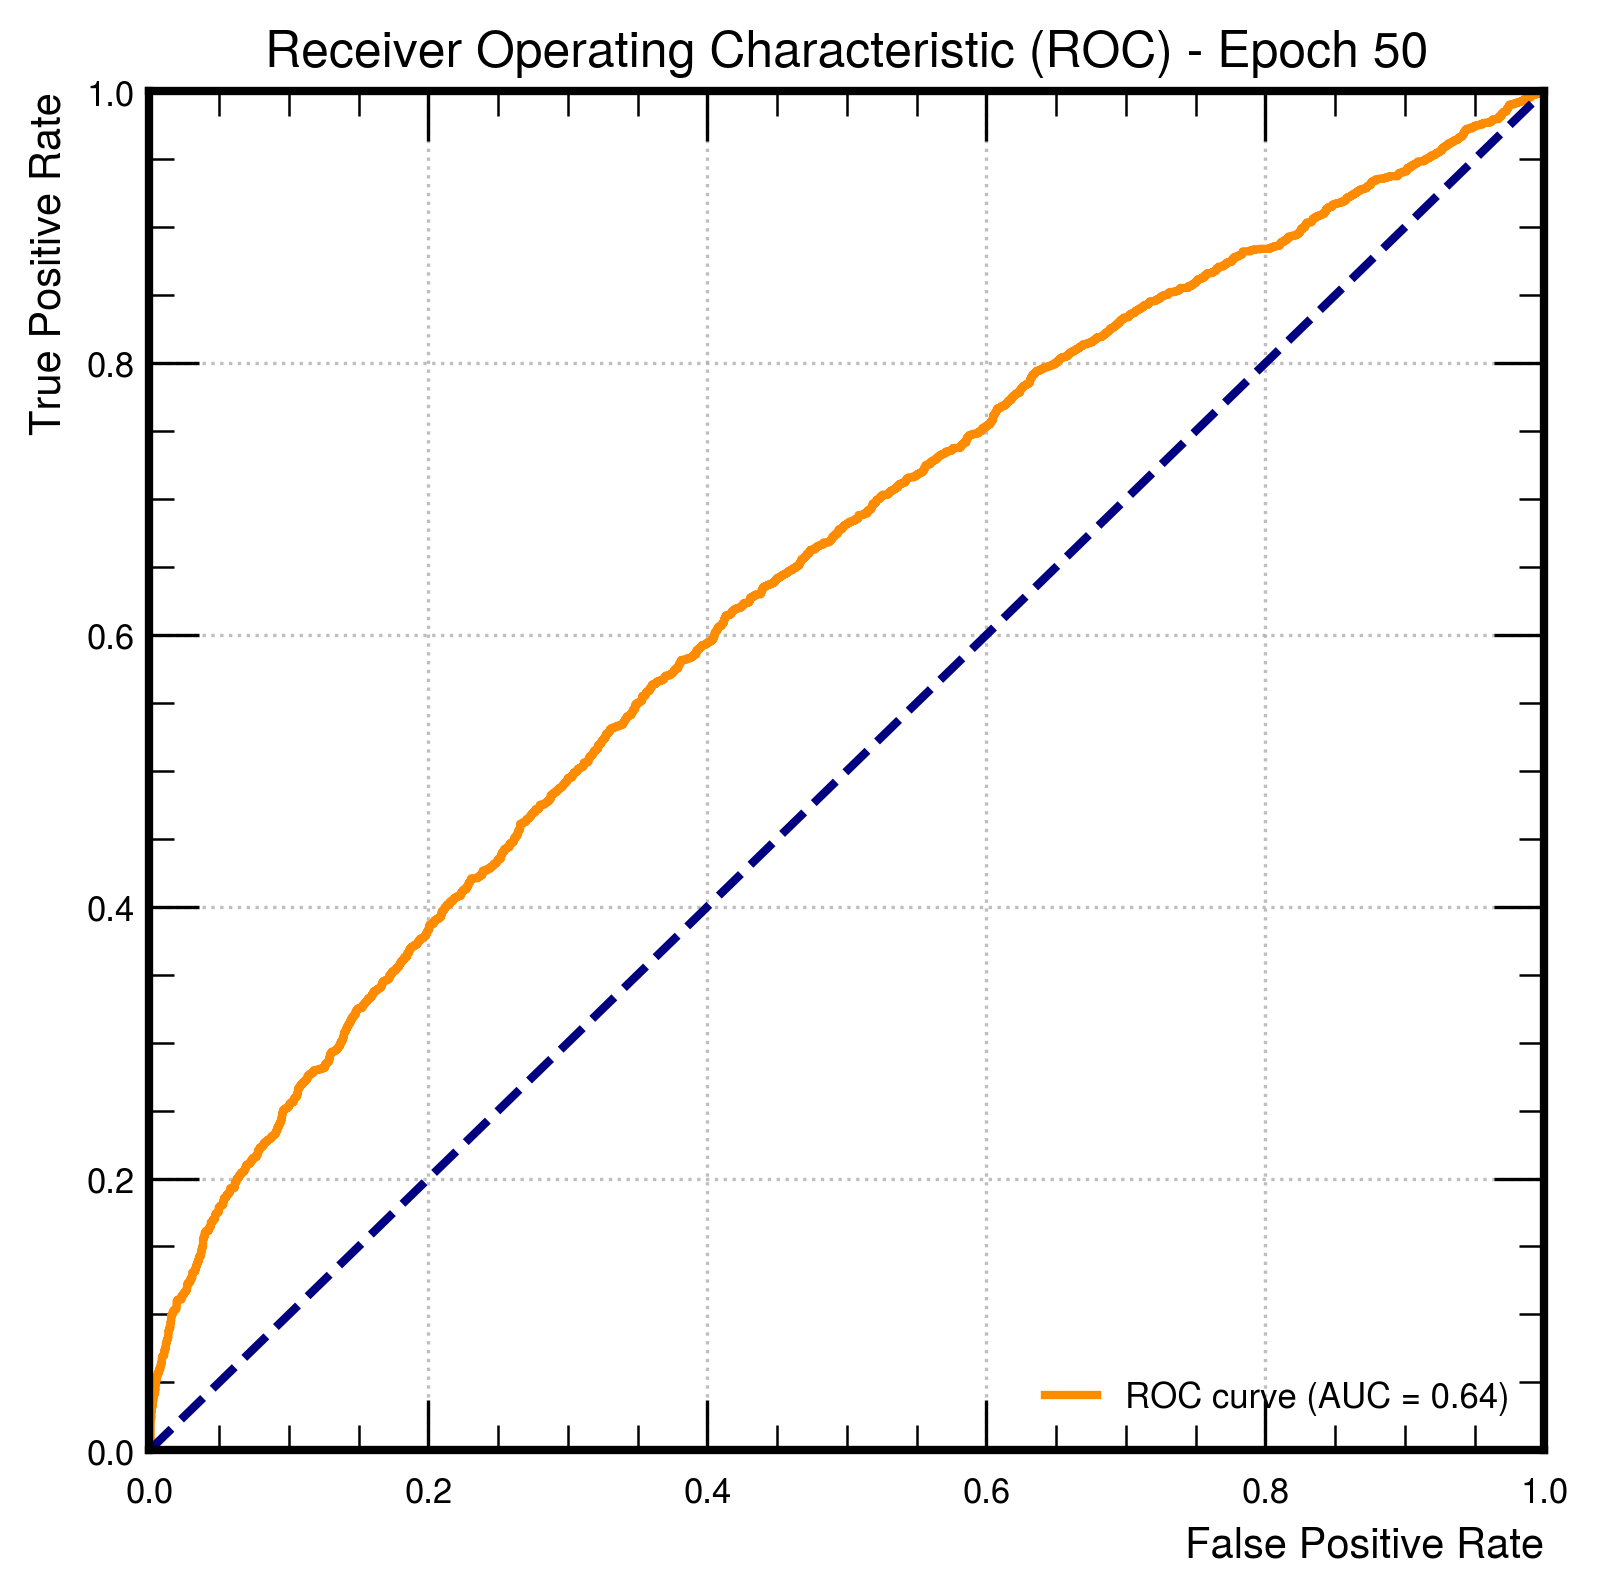

In [154]:
# Calculate ROC and AUC for validation
fpr, tpr, _ = roc_curve(all_true_labels_lastEpoch, all_pred_probs_lastEpoch)
roc_auc = auc(fpr, tpr)

# Plot ROC curve for validation
plt.figure(dpi=300, facecolor='white',figsize=(6,6))
# plt.axis("equal")
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) - Epoch {epoch + 1}')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("ROCNew.png")